#Projeto Tabacarias




# Bibliotecas

In [1]:
import datetime
import matplotlib.pyplot as plt
import pandas as pd
import folium

# Armazenar

In [2]:
tabacarias = {}
produtos = {}
vendas = []
utilizadores = {}

# Função de Registos


In [3]:
def registar_tabacaria(nome, morada, horario, latitude, longitude):
    if not nome or not morada or not horario or not latitude or not longitude:
        print("Erro: Todos os campos (nome, morada, horario, latitude, longitude) são obrigatórios!")
        return

    try:
        latitude = float(latitude)
        longitude = float(longitude)
    except ValueError:
        print("Erro: Latitude e Longitude devem ser números válidos.")
        return

    if not (-90 <= latitude <= 90) or not (-180 <= longitude <= 180):
        print("Erro: Latitude deve estar entre -90 e 90. Longitude deve estar entre -180 e 180.")
        return

    if nome in tabacarias:
        print("Tabacaria já existe!")
        return

    tabacarias[nome] = {
        "Morada": morada,
        "Horario": horario,
        "lat": latitude,
        "lon": longitude,
        "CriadoEm": datetime.datetime.now()
    }

    print(f" Tabacaria '{nome}' registada!")


def registar_produto(nome, tipo, preco):
    if not nome or not tipo:
        print("Erro: Os campos (nome, tipo) são obrigatórios!")
        return

    try:
        preco = float(preco)
    except ValueError:
        print("Erro: Preço deve ser um número válido.")
        return

    if preco <= 0:
        print("Erro: Preço deve ser um valor positivo.")
        return

    if nome in produtos:
        print("Produto já existe!")
        return

    produtos[nome] = {
        "Tipo": tipo,
        "Preco": preco
    }

    print(f"Produto '{nome}' registado!")


def registar_utilizador(nome, nif):
    if not nome or not nif:
        print("Erro: Os campos (nome, NIF) são obrigatórios!")
        return

    if not nif.isdigit() or len(nif) != 9:
        print("Erro: NIF deve conter 9 dígitos numéricos.")
        return

    if nif in utilizadores:
        print("Utilizador já existe!")
        return

    utilizadores[nif] = {
        "Nome": nome,
        "NIF": nif
    }

    print(f"Utilizador '{nome}' registado!")


def registar_venda(tabacaria, produto, quantidade):
    if not tabacaria or not produto:
        print("Erro: Os campos (tabacaria, produto) são obrigatórios!")
        return

    try:
        quantidade = int(quantidade)
    except ValueError:
        print("Erro: Quantidade deve ser um número inteiro válido.")
        return

    if quantidade <= 0:
        print("Erro: Quantidade deve ser um valor positivo.")
        return

    if tabacaria not in tabacarias:
        print("Tabacaria não existe!")
        return

    if produto not in produtos:
        print("Produto não existe!")
        return

    total = produtos[produto]["Preco"] * quantidade

    venda = {
        "Tabacaria": tabacaria,
        "Produto": produto,
        "Quantidade": quantidade,
        "Total": total,
        "Data": datetime.datetime.now()
    }

    vendas.append(venda)

    print(f"Venda registada! Total: {total}€")

# Funções para Consultas

In [4]:
def consultar_tabacarias():
    if not tabacarias:
        print("Sem tabacarias registadas.")
        return

    for nome, dados in tabacarias.items():
        print(f"\n {nome}")
        print(f"Morada: {dados['Morada']}")
        print(f"Horário: {dados['Horario']}")


def consultar_vendas():
    if not vendas:
        print("Sem vendas.")
        return

    for v in vendas:
        print(f"\n {v['Tabacaria']} | {v['Produto']}")
        print(f"Quantidade: {v['Quantidade']}")
        print(f"Total: {v['Total']}€")
        print(f"Data: {v['Data']}")


def consultar_vendas_por_tabacaria(nome):
    resultado = [v for v in vendas if v["Tabacaria"] == nome]

    if not resultado:
        print("Sem vendas para essa tabacaria.")
        return

    print(f"\n Vendas - {nome}")
    for v in resultado:
        print(f"{v['Produto']} - {v['Quantidade']} unidades - {v['Total']}€")

# Funções para Ranking

In [5]:
def ranking_tabacarias():
    ranking = {}

    for v in vendas:
        tab = v["Tabacaria"]
        ranking[tab] = ranking.get(tab, 0) + v["Total"]

    ranking_ordenado = sorted(ranking.items(), key=lambda x: x[1], reverse=True)

    print("\n Ranking de Tabacarias:")
    for i, (tab, total) in enumerate(ranking_ordenado, 1):
        print(f"{i}. {tab} - {total}€")

# Mapa

In [6]:
ponto=[]

def set_ponto(nome, horario, lon, lat):
  ponto.append({'nome':nome, 'horario':horario, 'lat':lat, 'lon':lon})
  return(ponto)

def del_ponto(nome):
  # ....
  status='to be defined'
  return(status)

def lista_pontos():
  kp=1
  for p in ponto:
    print(f"{kp:4d} {p['nome']:50s} {p['horario']:20s} ({p['lat']:.6f}, {p['lon']:.6f})")
    kp+=1
  return

def get_gjson():
  gjson={
  "type": "FeatureCollection",
  "features": []}

  for p in ponto:
    gjson['features'].append( {
      "type": "Feature",
      "properties": { "popupContent":f"<div width:400px>{p['nome']}</div>"},
      "geometry": {
        "coordinates": [
          p['lon'],
          p['lat']
        ],
        "type": "Point"
      } }
     )

  return(gjson)

In [7]:
set_ponto('O Tabaquinho', '08:00-20:00', -8.622233775982146,          41.2326189247205)
set_ponto('MaiaTims','09:00-19:00', -8.624835805946502,         41.23355062280917)
set_ponto('NClips', '08:00-20:00', -8.617684270566329,  41.260585604847435)
set_ponto('Papelaria Gracimar', '09:00-19:00', -8.603720121918254,  41.21869790686659)

[{'nome': 'O Tabaquinho',
  'horario': '08:00-20:00',
  'lat': 41.2326189247205,
  'lon': -8.622233775982146},
 {'nome': 'MaiaTims',
  'horario': '09:00-19:00',
  'lat': 41.23355062280917,
  'lon': -8.624835805946502},
 {'nome': 'NClips',
  'horario': '08:00-20:00',
  'lat': 41.260585604847435,
  'lon': -8.617684270566329},
 {'nome': 'Papelaria Gracimar',
  'horario': '09:00-19:00',
  'lat': 41.21869790686659,
  'lon': -8.603720121918254}]

In [8]:
lista_pontos()

   1 O Tabaquinho                                       08:00-20:00          (41.232619, -8.622234)
   2 MaiaTims                                           09:00-19:00          (41.233551, -8.624836)
   3 NClips                                             08:00-20:00          (41.260586, -8.617684)
   4 Papelaria Gracimar                                 09:00-19:00          (41.218698, -8.603720)


In [9]:
import requests
import json

# Exemplo da HU 'Marca os pontos e o polígono que define o Concelho da Maia'

# Vamos primeiro importar os limites do Concelho da Maia a uma fonte credível
aline=requests.get('http://baze.cm-maia.pt/BaZe/api/api4gj.php?nome=LimConcVM')
#aline=requests.get('http://195.23.9.30/BaZe/api/api4gj.php?nome=LimConcVM',  verify=False)

aline=aline.text[1:]
agj = json.loads(aline)

In [10]:
from folium.plugins import GroupedLayerControl

# Create the map at Maia
m = folium.Map(location=[41.22, -8.5795], zoom_start=12, width=900,   height=700)  # height in pixels)

folium.TileLayer('openstreetmap', name='OpenStreetMap').add_to(m)
folium.TileLayer('cartodbpositron', name='CartoDB Positron').add_to(m)
folium.TileLayer('cartodbdark_matter', name='CartoDB Dark').add_to(m)
#folium.TileLayer('Stamen Terrain', name='Stamen Terrain').add_to(m)
#folium.TileLayer('Stamen Toner', name='Stamen Toner').add_to(m)
folium.TileLayer('https://{s}.tile.opentopomap.org/{z}/{x}/{y}.png',
                 name='OpenTopoMap',
                 attr='Map data: © OpenStreetMap contributors').add_to(m)
folium.TileLayer(
    tiles='https://mt1.google.com/vt/lyrs=s&x={x}&y={y}&z={z}',
    attr='Google',
    name='Google Satellite'
).add_to(m)

# Add Google Terrain
folium.TileLayer(
    tiles='https://mt1.google.com/vt/lyrs=p&x={x}&y={y}&z={z}',
    attr='Google',
    name='Google Terrain'
).add_to(m)

folium.GeoJson(
    agj,
    name='Limite do Concelho'
).add_to(m)

folium.LayerControl().add_to(m)

# Add markers
for p in ponto:
    folium.Marker(location=[p["lat"], p["lon"]], popup=p["nome"]).add_to(m)

# output para ficheiro mapa.html
m.save( "mapa.html")

# Visualização do mapa
def mapa():
  display(m)

# Graficos

In [11]:
def grafico_vendas_tabacaria():
    totais = {}

    for v in vendas:
        tab = v["Tabacaria"]
        totais[tab] = totais.get(tab, 0) + v["Total"]

    nomes = list(totais.keys())
    valores = list(totais.values())

    plt.figure()
    plt.bar(nomes, valores)
    plt.title("Vendas por Tabacaria")
    plt.xlabel("Tabacarias")
    plt.ylabel("Total (€)")
    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.show()


def grafico_produtos():
    totais = {}

    for v in vendas:
        prod = v["Produto"]
        totais[prod] = totais.get(prod, 0) + v["Quantidade"]

    nomes = list(totais.keys())
    valores = list(totais.values())

    plt.figure()
    plt.bar(nomes, valores)
    plt.title("Produtos Mais Vendidos")
    plt.xlabel("Produtos")
    plt.ylabel("Quantidade")
    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.show()

# Testes

In [12]:
# Adicionar utilizadores
registar_utilizador("Joao", "123456789")
registar_utilizador("Gustavo", "176548976")
registar_utilizador("Pedro", "198723451")
registar_utilizador("Serrano", "253678903")
registar_utilizador("Rafael", "1986736478")

Utilizador 'Joao' registado!
Utilizador 'Gustavo' registado!
Utilizador 'Pedro' registado!
Utilizador 'Serrano' registado!
Erro: NIF deve conter 9 dígitos numéricos.


In [13]:
# Registar produtos
registar_produto("Jornal Público", "Jornal", 1.5)
registar_produto("Revista Sábado", "Revista", 2.0)
registar_produto("Jornal A bola", "Jornal", 2.0)
registar_produto("Jornal O Jogo", "Jornal", 2.0)
registar_produto("JN", "Jornal", 3.0)

Produto 'Jornal Público' registado!
Produto 'Revista Sábado' registado!
Produto 'Jornal A bola' registado!
Produto 'Jornal O Jogo' registado!
Produto 'JN' registado!


In [14]:
# Registar tabacarias
registar_tabacaria("O Tabaquinho", "Rua A, Porto", "08:00-20:00",  "41.2326189247205", "-8.622233775982146")
registar_tabacaria("MaiaTims", "Rua B, Braga", "09:00-19:00",  "41.23355062280917", "-8.624835805946502")
registar_tabacaria("NClips", "Rua A, Porto", "08:00-20:00",  "41.260585604847435", "-8.617684270566329")
registar_tabacaria("Papelaria Gracimar", "Rua B, Braga", "09:00-19:00",  "41.21869790686659", "-8.603720121918254")

 Tabacaria 'O Tabaquinho' registada!
 Tabacaria 'MaiaTims' registada!
 Tabacaria 'NClips' registada!
 Tabacaria 'Papelaria Gracimar' registada!


In [15]:
# Vendas
registar_venda("O Tabaquinho", "Jornal Público", 10)
registar_venda("NClips", "Revista Sábado", 5)
registar_venda("MaiaTims", "Jornal A bola", 4)
registar_venda("MaiaTims", "Jornal O Jogo", 9)
registar_venda("Papelaria Gracimar", "JN", 10)

Venda registada! Total: 15.0€
Venda registada! Total: 10.0€
Venda registada! Total: 8.0€
Venda registada! Total: 18.0€
Venda registada! Total: 30.0€


In [16]:
# Consultas
consultar_tabacarias()
consultar_vendas()



 O Tabaquinho
Morada: Rua A, Porto
Horário: 08:00-20:00

 MaiaTims
Morada: Rua B, Braga
Horário: 09:00-19:00

 NClips
Morada: Rua A, Porto
Horário: 08:00-20:00

 Papelaria Gracimar
Morada: Rua B, Braga
Horário: 09:00-19:00

 O Tabaquinho | Jornal Público
Quantidade: 10
Total: 15.0€
Data: 2026-04-06 11:29:05.410839

 NClips | Revista Sábado
Quantidade: 5
Total: 10.0€
Data: 2026-04-06 11:29:05.410989

 MaiaTims | Jornal A bola
Quantidade: 4
Total: 8.0€
Data: 2026-04-06 11:29:05.411076

 MaiaTims | Jornal O Jogo
Quantidade: 9
Total: 18.0€
Data: 2026-04-06 11:29:05.412230

 Papelaria Gracimar | JN
Quantidade: 10
Total: 30.0€
Data: 2026-04-06 11:29:05.412353


In [17]:
consultar_vendas_por_tabacaria("MaiaTims")


 Vendas - MaiaTims
Jornal A bola - 4 unidades - 8.0€
Jornal O Jogo - 9 unidades - 18.0€


In [18]:
# Ranking
ranking_tabacarias()


 Ranking de Tabacarias:
1. Papelaria Gracimar - 30.0€
2. MaiaTims - 26.0€
3. O Tabaquinho - 15.0€
4. NClips - 10.0€


In [19]:
# Mapa
mapa()

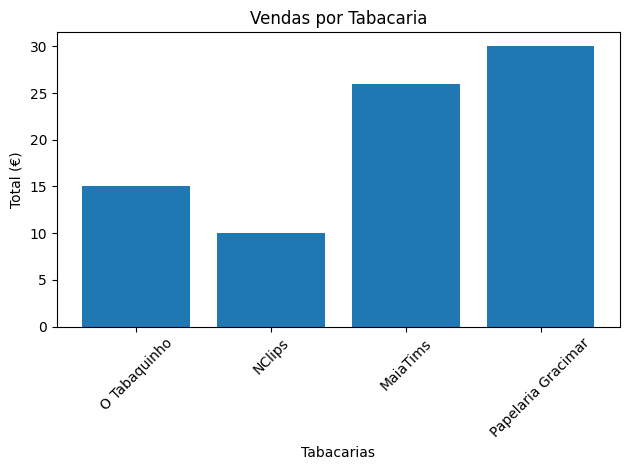

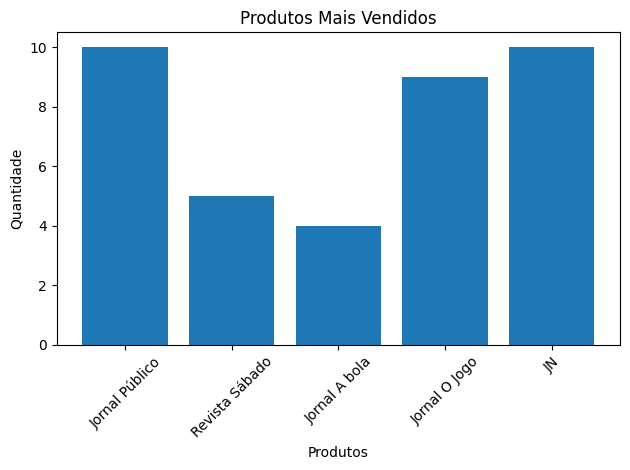

In [20]:
# Gráficos
grafico_vendas_tabacaria()
grafico_produtos()